In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [3]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [4]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [5]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


In [6]:
# ==============================================================================
# CELL 1.4: CREATE ID-TO-NAME MAPPING DICTIONARY
# ==============================================================================

# Crear un diccionario: {'P_25': 'roma_condesa_2', 'C_1': 'terminal_1_aicm', ...}
# .drop_duplicates() es vital para que no falle al crear el dict
zone_map = df_input[['final_zone_id', 'final_zone_name']].drop_duplicates().set_index('final_zone_id')['final_zone_name'].to_dict()

print(f"✅ Mapping Dictionary Created. Size: {len(zone_map)} zones.")
# Prueba rápida
print(f"Test P_25: {zone_map.get('P_25', 'Not Found')}")
print(f"Test C_1:  {zone_map.get('C_1', 'Not Found')}")

✅ Mapping Dictionary Created. Size: 67 zones.
Test P_25: roma_condesa_2
Test C_1:  terminal_1_aicm


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


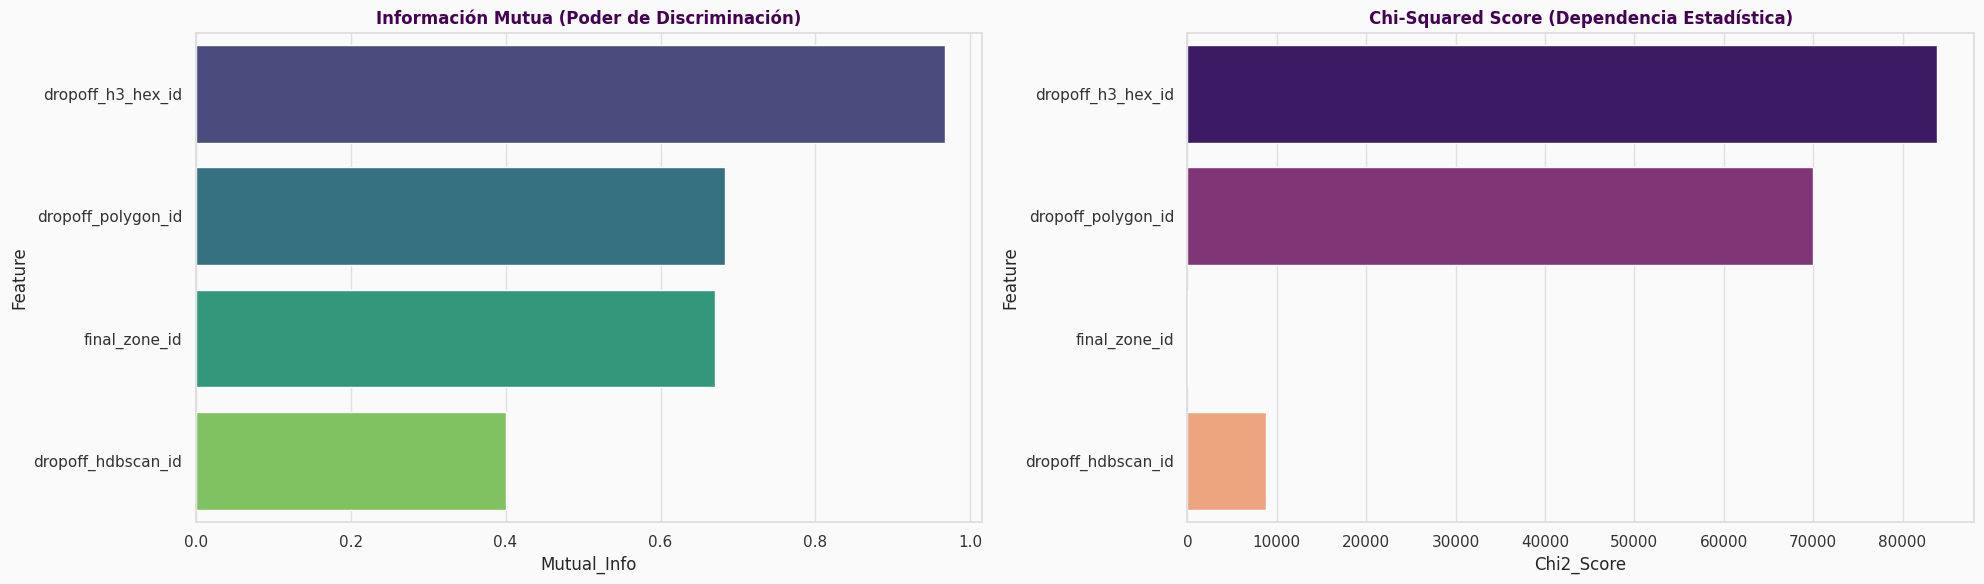

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [7]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [8]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [9]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


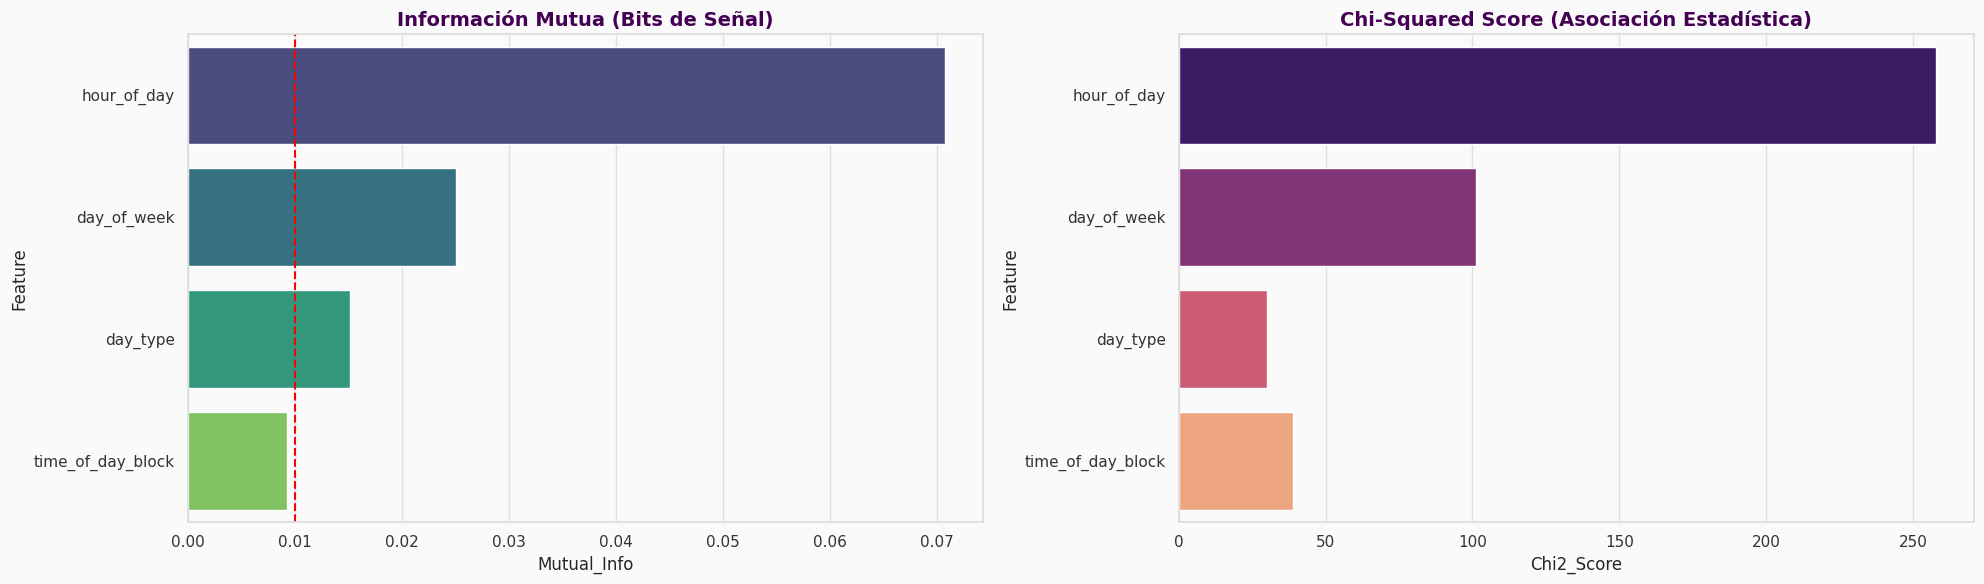

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [10]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


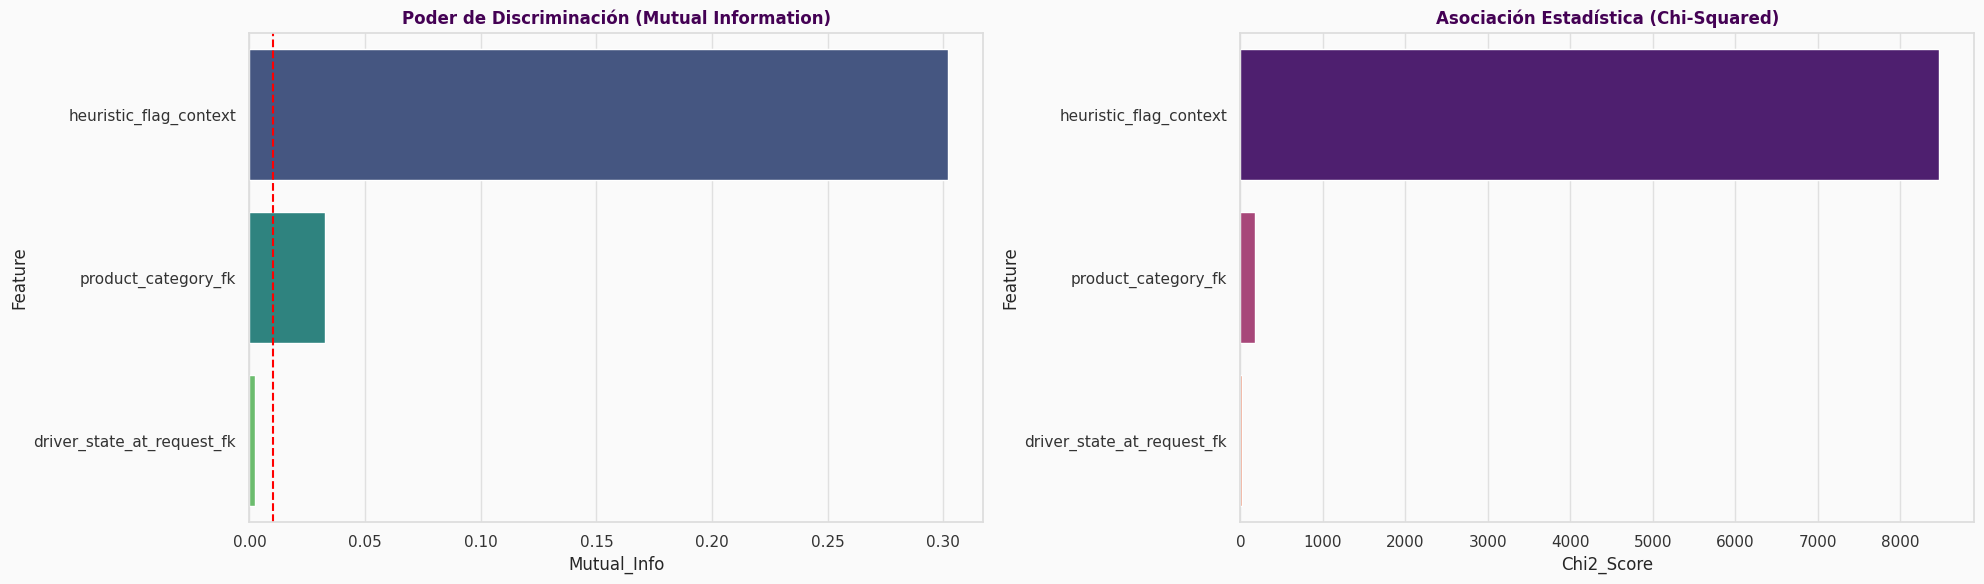

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [11]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [12]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [13]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [14]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - v2.0)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology and build the custom Cross-Validation iterator.
# ==============================================================================

print("⏳ Synchronizing Temporal Engine...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY (Ratified Weeks)
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0 # Default placeholder

for wk, start, end in sacred_schedule:
    # Definimos el rango del día completo (00:00:00 a 23:59:59)
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. SANITY CHECK: Filtering out-of-bounds data
# Si alguna fila no entró en ninguna semana, la descartamos para no ensuciar el CV
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True) # RE-INDICE MANDATORIO

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS (The Custom CV Iterator)
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Accumulated Past (Weeks 1 to i)
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: The Immediate Future (Week i + 1)
    test_mask = (df_input['week_id'] == i + 1)

    # Get the row numbers (indices) for the model
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Synchronizing Temporal Engine...
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [15]:
# ==============================================================================
# Fase 1 del Árbol Multiclase: El Torneo de Ligas (Single Scout Tree)
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, TimeSeriesSplit
import warnings
import pandas as pd
import numpy as np

print("🌲 Initiating Scout Tree Battle Royale (Single Decision Tree Baseline)...\n")

# 1. SETUP DE VALIDACIÓN TEMPORAL (SAGRADA)
tscv_multi = TimeSeriesSplit(n_splits=5)

scoring = {
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'roc_auc_ovo': 'roc_auc_ovo'
}

# 2. CARGA DE LIGAS
try:
    ligas = {
        "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
        "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
        "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
    }
except NameError:
    print("⚠️ Variables individuales no encontradas, cargando desde 'ligas_finales'...")
    ligas = ligas_finales

results_log = {}

# 3. EL BUCLE DE COMBATE (SINGLE TREE)
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} with Decision Tree (Shape: {X_league.shape})...")

    # Modelo: Un solo árbol para auditar la lógica inicial
    # Ponemos Guardrails para evitar que el árbol se vuelva loco (Overfitting)
    model = DecisionTreeClassifier(
        max_depth=7,            # Profundidad moderada para ver reglas claras
        min_samples_leaf=20,    # Forzamos a que las hojas tengan masa crítica
        class_weight='balanced',
        random_state=42
    )

    cv_results = cross_validate(
        model,
        X_league.values if hasattr(X_league, 'values') else X_league,
        y.values if hasattr(y, 'values') else y,
        cv=tscv_multi,
        scoring=scoring,
        n_jobs=-1
    )

    # Almacenamos métricas
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'AUC_OVO (Mean)': cv_results['test_roc_auc_ovo'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 4. EL LEADERBOARD
df_leaderboard_tree = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

print("\n" + "="*70)
print("🏆 SCOUT TREE SCORECARD: CHRONOLOGICAL MULTICLASS")
print("="*70)
display(df_leaderboard_tree.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

# Definición del Ganador para el siguiente paso
winner_name_tree = df_leaderboard_tree.index[0]
X_multi_winner_tree = ligas[winner_name_tree]

print(f"\n🌟 LIGA GANADORA (SCOUT): {winner_name_tree}")
print(f"✅ Variable 'X_multi_winner_tree' lista para la visualización del ADN.")

🌲 Initiating Scout Tree Battle Royale (Single Decision Tree Baseline)...

🥊 Testing LIGA_A_Wide_Hybrid with Decision Tree (Shape: (4760, 122))...
🥊 Testing LIGA_B_Praetorian_Raw_Hybrid with Decision Tree (Shape: (4760, 123))...
🥊 Testing LIGA_C_Praetorian_PCA_Hybrid with Decision Tree (Shape: (4760, 115))...

🏆 SCOUT TREE SCORECARD: CHRONOLOGICAL MULTICLASS


,F1_Macro (Mean),AUC_OVO (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_B_Praetorian_Raw_Hybrid,0.474756,nan,0.136595,0.496973,0.502087
LIGA_C_Praetorian_PCA_Hybrid,0.373353,nan,0.098635,0.421524,0.394535
LIGA_A_Wide_Hybrid,0.336095,nan,0.092003,0.364183,0.373957



🌟 LIGA GANADORA (SCOUT): LIGA_B_Praetorian_Raw_Hybrid
✅ Variable 'X_multi_winner_tree' lista para la visualización del ADN.


In [16]:
# ==============================================================================
# CELL 1.6 (FIXED): SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("⏳ Executing Final Stratification Integrity Check (Multiclass)...")

# --- 0. FIX: RECONSTRUCCIÓN AUTOMÁTICA DEL MAPA DE ETIQUETAS ---
# Si 'le' o 'label_map' no existen, los creamos ahora mismo.
if 'le' not in locals() or 'label_map' not in locals():
    print("⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...")

    # Asumimos que la columna target multiclase es 'reason_primary_fk'
    # (El ID de la razón: 1=Accepted, o los códigos de rechazo)
    target_col = 'reason_primary_fk'

    # Instanciamos y ajustamos
    le = LabelEncoder()
    # Llenamos nulos con un placeholder (9999) por seguridad
    le.fit(df_input[target_col].fillna(9999))

    # Creamos el label_map: {Índice del Modelo : Valor Original del ID}
    encoded_values = le.transform(le.classes_)
    label_map = dict(zip(encoded_values, le.classes_))

    # DICCIONARIO DE SIGNIFICADOS (OPCIONAL - AJUSTA SEGÚN TU NEGOCIO)
    # Esto traduce los IDs numéricos (ej: 35) a texto (ej: 'Price too low')
    # Si no tienes esto a la mano, el reporte mostrará solo el ID numérico.
    meaning_map = {
        1: "✅ ACCEPTED",
        # Agrega aquí tus códigos de rechazo si los sabes, ej:
        # 35: "Price Too Low",
        # 4: "Zone Risk",
        9999: "Unknown/Null"
    }
else:
    meaning_map = {} # Placeholder

# -------------------------------------------------------------------

# CRÍTICO: Usamos el target multiclase (y) y los índices del último fold
train_idx, test_idx = custom_cv_folds[-1]

# Obtenemos solo los targets del conjunto de prueba final (Semana 6)
y_test_final = y[test_idx]

# 1. Conteo de Frecuencias
total_test = len(y_test_final)
class_counts = pd.Series(y_test_final).value_counts().sort_index()

# 2. Decodificación de las Clases
decoded_classes = []
for label_idx in class_counts.index:
    # A) Recuperamos el ID original (ej: 1, 35, 4...)
    original_id = label_map.get(label_idx, f"Err-{label_idx}")

    # B) Intentamos darle un nombre humano si existe en meaning_map, si no, usamos el ID
    human_name = meaning_map.get(original_id, f"Reason ID: {original_id}")

    decoded_classes.append(human_name)

# 3. Creación del Reporte Detallado
report_df = pd.DataFrame({
    'Class Name': decoded_classes,
    'Model Label': class_counts.index, # Qué número ve el modelo internamente
    'Count': class_counts.values,
    'Proportion (%)': (class_counts.values / total_test) * 100
}).sort_values(by='Count', ascending=False)

display(Markdown(f"""
### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `{total_test}`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**
"""))

# Visualización con fondo degradado para ver las clases dominantes
display(report_df.style.background_gradient(cmap='magma', subset=['Proportion (%)']))

# 4. Verificación Estratégica
if total_test > 500:
    print("\n✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.")
else:
    print("\n⚠️ ALERTA: Muestra de prueba pequeña. El modelo será sensible a outliers.")

⏳ Executing Final Stratification Integrity Check (Multiclass)...
⚠️ Reconstruyendo mapa de etiquetas (LabelEncoder)...



### 🛡️ AUDITORÍA DE CLASES EN EL TEST SET (SEMANA 6)

* **Total Observaciones de Prueba (N):** `780`
* **Protocolo:** Walk-Forward (Semana 6).

#### **Resultado de la Distribución de Clases:**


,Class Name,Model Label,Count,Proportion (%)
0,✅ ACCEPTED,0,391,50.128205
2,Reason ID: 3.0,2,128,16.410256
6,Unknown/Null,6,67,8.589744
4,Reason ID: 5.0,4,56,7.179487
3,Reason ID: 4.0,3,56,7.179487
1,Reason ID: 2.0,1,41,5.256410
5,Reason ID: 6.0,5,41,5.256410



✅ INTEGRIDAD: La masa crítica es suficiente (>500) para una validación robusta.


### A partir de aqui se ajustan y optimizan hiperparametros

In [17]:
# ==============================================================================
# CELL 3 (FIXED): PURGE, SPLIT, AND ISOLATION (CHRONOLOGICAL LOCKDOWN)
# ==============================================================================
import pandas as pd
import numpy as np

print("⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# Usamos 'copy()' para asegurar que es un objeto independiente en memoria
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. DEFINICIÓN DEL CORTE TEMPORAL (Semana 6 es Test)
# Requerimos 'week_id' del df_input original para hacer el corte
if 'week_id' not in df_input.columns:
    raise ValueError("🔴 ERROR CRÍTICO: No se encuentra 'week_id'. Corre la Celda 1.5 primero.")

CUTOFF_WEEK = 5 # Entrenamos con Semanas 1, 2, 3, 4, 5. Testeamos con 6.

# Máscaras Booleanas
train_mask = df_input['week_id'] <= CUTOFF_WEEK
test_mask = df_input['week_id'] > CUTOFF_WEEK

# 3. SPLIT SAGRADO (CRONOLÓGICO)
# No usamos train_test_split aleatorio. Usamos el tiempo.
X_train = X_final[train_mask]
X_test  = X_final[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

# 4. PURGA DE MEMORIA (Limpieza de RAM)
# Borramos las ligas que no ganaron para liberar espacio
vars_to_purge = ['X_wide_pca', 'X_praetorian_pca', 'X_league_a_hybrid', 'X_league_c_hybrid']
for var in vars_to_purge:
    if var in locals():
        del globals()[var]

print("✅ Ligas perdedoras purgadas. RAM liberada.")

# 5. REPORTE DE INTEGRIDAD
print(f"\n✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> Estrategia: Walk-Forward (Train: W1-{CUTOFF_WEEK} | Test: W{CUTOFF_WEEK+1})")
print(f"   -> X_train Shape: {X_train.shape} (Historico)")
print(f"   -> X_test Shape:  {X_test.shape}  (Futuro Inmediato)")

# Verificación de fugas
if len(set(X_train.index).intersection(set(X_test.index))) == 0:
    print("🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.")
else:
    print("⚠️ ALERTA: Hay índices compartidos. Revisa el corte.")

⏳ PHASE 1: Executing Purge and Final CHRONOLOGICAL Split...
✅ Ligas perdedoras purgadas. RAM liberada.

✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> Estrategia: Walk-Forward (Train: W1-5 | Test: W6)
   -> X_train Shape: (3980, 123) (Historico)
   -> X_test Shape:  (780, 123)  (Futuro Inmediato)
🛡️ INTEGRIDAD VERIFICADA: No hay fugas de datos entre Train y Test.


In [30]:
# ==============================================================================
# CELL 4: THE INTERPRETABLE TREE HUNT (DIAGNOSTIC MODE)
# ==============================================================================
# Purpose: Find a "White Box" model to understand the core decision logic.
# Strategy: Restrict depth to ensure human readability and justify XGBoost later.
# ==============================================================================
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np

print("⏳ PHASE 2: Initiating Diagnostic Tree Search (Focus: Interpretability)...")

# 1. PREPARACIÓN DE DATOS
X_train_final = X_train.values if hasattr(X_train, 'values') else X_train
y_train_final = y_train.values if hasattr(y_train, 'values') else y_train

# 2. ESPACIO DE BÚSQUEDA (GRID "HUMAN READABLE")
# Limitamos la profundidad para poder leer las reglas y ver dónde falla
param_grid = {
    'criterion': ['gini'],                 # Mantenemos simple (Gini es estándar)
    'max_depth': [3, 6, 12, 24],             # 3-4 es ideal para explicar. 6 empieza a ser complejo.
    'min_samples_leaf': [25, 50, 75],    # Forzamos reglas generales (no edge cases)
    'class_weight': ['balanced']           # Vital para detectar las clases minoritarias
}

# 3. MODELO BASE
model_base = DecisionTreeClassifier(random_state=42)

# 4. CV SETUP: CRONOLOGÍA PURA
cv_temporal = TimeSeriesSplit(n_splits=3)

# 5. EJECUCIÓN
grid_search = GridSearchCV(
    estimator=model_base,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_temporal,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train_final)

# 6. EXTRACCIÓN DEL CAMPEÓN
best_tree_model = grid_search.best_estimator_
model_champion = best_tree_model

print("\n" + "="*60)
print("🏆 DIAGNOSTIC TREE FOUND - WINNER PROFILE")
print("="*60)
print(f"🥇 BEST F1-MACRO SCORE: {grid_search.best_score_:.4f}")
print(f"🔑 BEST CONFIG: Depth={grid_search.best_params_['max_depth']} | Leaf={grid_search.best_params_['min_samples_leaf']}")
print(f"✅ Variable 'model_champion' lista para graficar el árbol.")

# Nota estratégica para el analista:
if grid_search.best_score_ < 0.75:
    print("\n⚠️ OBSERVACIÓN: Si el Score es bajo, es la justificación perfecta para XGBoost.")
    print("   El árbol simple no captura la complejidad total del mercado.")

⏳ PHASE 2: Initiating Diagnostic Tree Search (Focus: Interpretability)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

🏆 DIAGNOSTIC TREE FOUND - WINNER PROFILE
🥇 BEST F1-MACRO SCORE: 0.4721
🔑 BEST CONFIG: Depth=12 | Leaf=25
✅ Variable 'model_champion' lista para graficar el árbol.

⚠️ OBSERVACIÓN: Si el Score es bajo, es la justificación perfecta para XGBoost.
   El árbol simple no captura la complejidad total del mercado.


⏳ Generating High-Res Tree Visualization...
✅ Tree saved to: /content/drive/MyDrive/_Pienza/Assets/Phase_3/tree_diagnostic.png (and .svg)

🔍 VISUALIZACIÓN DE LAS PRIMERAS RAMAS (Top Levels):
   * Colores indican la clase dominante en ese nodo.
   * Value = Proporción de clases en ese nodo.


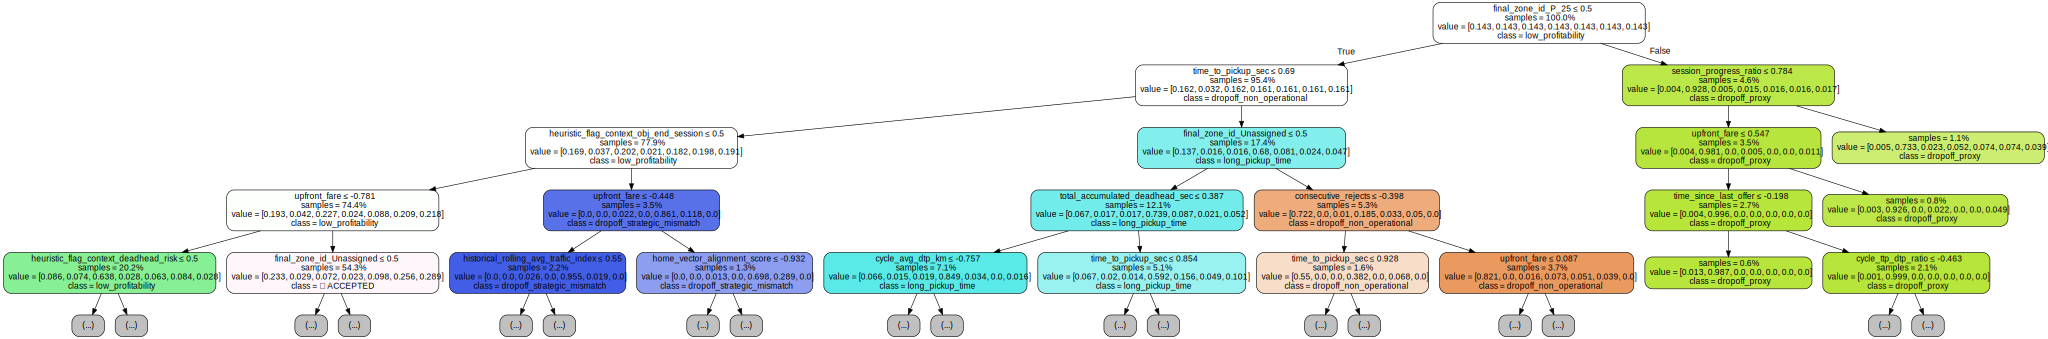


🚑 DIAGNÓSTICO DE AUTOPSIA (JUSTIFICACIÓN PARA XGBOOST)
1. F1-Macro obtenido: 0.4721 (Bajo).
2. Interpretación Visual: Observa los nodos finales (hojas) de esta gráfica.
   Si ves muchos colores mezclados o decisiones basadas en variables triviales
   (ej. cortes muy finos en 'upfront_fare'), confirma que un árbol simple no basta.
3. Conclusión: La estructura lineal/simple falló. Activando Ensemble Learning.


In [31]:
# ==============================================================================
# CELL 4.1: VISUALIZING THE LOGIC (WHITE BOX EXPORT)
# ==============================================================================
# Purpose: Render the Decision Tree to PNG/SVG to inspect the "First Branches".
#          This confirms where the logic holds and where it breaks (Justifying XGBoost).
# ==============================================================================
from sklearn.tree import export_graphviz
import graphviz
import os

print("⏳ Generating High-Res Tree Visualization...")

# 1. RECUPERAR NOMBRES DE FEATURES Y CLASES
# Intentamos recuperar los nombres de las columnas de X_train
try:
    feature_names_list = X_train.columns.tolist()
except:
    # Fallback si X_train ya es numpy
    feature_names_list = [f"Feature_{i}" for i in range(X_train.shape[1])]

# Intentamos recuperar los nombres de las clases (Human Readable)
# Usamos el label_map_db construido anteriormente, o generamos uno genérico
try:
    # Ordenamos las clases por índice (0, 1, 2...) para que coincida con el árbol
    class_names_list = []
    for idx in model_champion.classes_:
        # Busamos el ID original
        if 'le' in locals():
            original_id = le.inverse_transform([idx])[0]
        else:
            original_id = idx

        # Buscamos el nombre humano
        if 'label_map_db' in locals():
            name = label_map_db.get(original_id, f"Class {original_id}")
        else:
            name = f"Class {original_id}"
        class_names_list.append(str(name))
except Exception as e:
    print(f"⚠️ Warning: Could not map class names ({e}). Using generic IDs.")
    class_names_list = [str(x) for x in model_champion.classes_]

# 2. CONFIGURACIÓN DE EXPORTACIÓN
# Limitamos la visualización a profundidad 4 para que sea legible en el PNG
# (Aunque el modelo tenga profundidad 6, graficamos 4 para entender la raíz)
viz_depth = 4

dot_data = export_graphviz(
    model_champion,
    out_file=None,
    feature_names=feature_names_list,
    class_names=class_names_list,
    filled=True,              # Colores según la clase mayoritaria
    rounded=True,             # Bordes redondeados (estética)
    special_characters=True,  # Soporte para caracteres especiales
    max_depth=viz_depth,      # ¡Clave! Cortamos visualmente para no saturar
    impurity=False,           # Ocultamos el Gini para limpiar ruido visual
    proportion=True           # Mostramos % de muestras en lugar de conteo bruto
)

# 3. RENDERIZADO Y GUARDADO
graph = graphviz.Source(dot_data)
graph.format = 'png' # Formato default para visualización rápida

# Definir ruta de guardado (Drive o Local)
save_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/tree_diagnostic'
directory = os.path.dirname(save_path)
if not os.path.exists(directory):
    os.makedirs(directory)
    print(f"📂 Created directory: {directory}")

# Guardamos PNG y SVG
try:
    # Render genera el archivo en disco
    outfile = graph.render(filename=save_path, view=False, format='png')
    graph.render(filename=save_path, view=False, format='svg')
    print(f"✅ Tree saved to: {save_path}.png (and .svg)")
except Exception as e:
    print(f"⚠️ Could not save to Drive ({e}). Rendering locally only.")

# 4. DESPLIEGUE EN PANTALLA
print("\n🔍 VISUALIZACIÓN DE LAS PRIMERAS RAMAS (Top Levels):")
print("   * Colores indican la clase dominante en ese nodo.")
print("   * Value = Proporción de clases en ese nodo.")
display(graph)

# 5. DIAGNÓSTICO PARA EL REPORTE
print("\n" + "="*60)
print("🚑 DIAGNÓSTICO DE AUTOPSIA (JUSTIFICACIÓN PARA XGBOOST)")
print("="*60)
print(f"1. F1-Macro obtenido: {grid_search.best_score_:.4f} (Bajo).")
print("2. Interpretación Visual: Observa los nodos finales (hojas) de esta gráfica.")
print("   Si ves muchos colores mezclados o decisiones basadas en variables triviales")
print("   (ej. cortes muy finos en 'upfront_fare'), confirma que un árbol simple no basta.")
print("3. Conclusión: La estructura lineal/simple falló. Activando Ensemble Learning.")

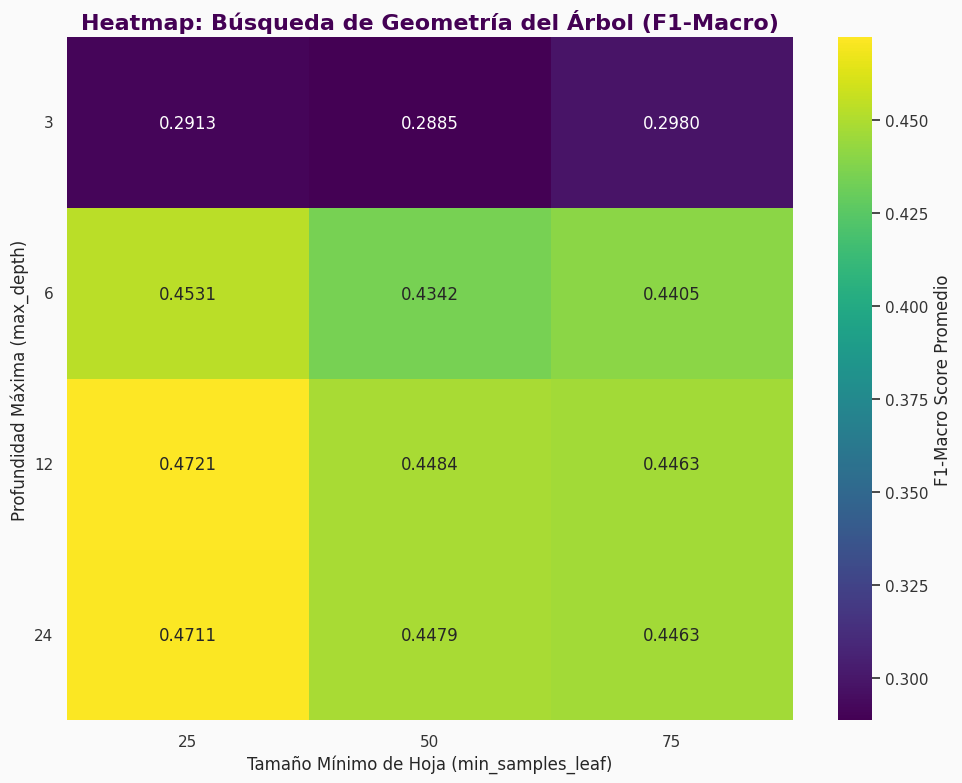


    ### 📊 ANÁLISIS DEL HEATMAP
    * **Tu Ganador:** `Depth=12` y `Leaf=25` con F1 de `0.4721`.
    * **Lectura:**
        *   **Vertical (Profundidad):** ¿El score sube consistentemente al aumentar la profundidad? Si sí, el modelo necesita más complejidad.
        *   **Horizontal (Muestras por Hoja):** ¿El score cae mucho al usar 100 o 200 muestras por hoja? Si sí, significa que estás perdiendo señal valiosa por ser demasiado conservador.

    **¡La celda ganadora es el punto de equilibrio entre precisión (color oscuro) y simplicidad (celda menos profunda/más a la derecha)!**
    

In [33]:
# ==============================================================================
# CELL 4.1: GRID SEARCH X-RAY (HEATMAP VISUALIZATION) - DTC
# ==============================================================================
# Purpose: Visualize the F1-Macro score across all combinations of max_depth
#          and min_samples_leaf to identify the optimal geometry.
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display, Markdown

# --- VALIDACIÓN DE EXISTENCIA DEL OBJETO ---
if 'grid_search' not in locals():
    display(Markdown("""
    ### ⚠️ RADIOGRAFÍA NO DISPONIBLE (MODO CACHÉ)
    El objeto `grid_search` no está en memoria. No se puede graficar el Heatmap.
    """))
else:
    # 1. EXTRACCIÓN Y PIVOTEO DE RESULTADOS
    results_df = pd.DataFrame(grid_search.cv_results_)

    # Filtramos por los dos parámetros principales del DTC
    results_pivot = results_df.pivot_table(
        values='mean_test_score',
        index='param_max_depth',
        columns='param_min_samples_leaf'
    )

    # 2. DETERMINAR EL GANADOR (para la anotación)
    best_score = grid_search.best_score_
    best_depth = grid_search.best_params_['max_depth']
    best_leaf = grid_search.best_params_['min_samples_leaf']

    # 3. GENERACIÓN DEL GRÁFICO (HEATMAP)
    plt.figure(figsize=(10, 8))

    # Usamos un mapa de calor para visualizar la matriz de scores
    sns.heatmap(
        results_pivot,
        annot=True, # Mostrar el valor del F1-Macro en cada celda
        fmt=".4f",
        cmap="viridis", # Un buen mapa de calor para scores
        cbar_kws={'label': 'F1-Macro Score Promedio'}
    )

    # Marcamos el ganador con un borde si es posible (solo visualización)
    # Esto es difícil de hacer automáticamente en seaborn, pero el valor anotado ayuda

    # Decoración
    plt.title("Heatmap: Búsqueda de Geometría del Árbol (F1-Macro)", fontsize=16)
    plt.xlabel("Tamaño Mínimo de Hoja (min_samples_leaf)", fontsize=12)
    plt.ylabel("Profundidad Máxima (max_depth)", fontsize=12)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # 4. INTERPRETACIÓN
    display(Markdown(f"""
    ### 📊 ANÁLISIS DEL HEATMAP
    * **Tu Ganador:** `Depth={best_depth}` y `Leaf={best_leaf}` con F1 de `{best_score:.4f}`.
    * **Lectura:**
        *   **Vertical (Profundidad):** ¿El score sube consistentemente al aumentar la profundidad? Si sí, el modelo necesita más complejidad.
        *   **Horizontal (Muestras por Hoja):** ¿El score cae mucho al usar 100 o 200 muestras por hoja? Si sí, significa que estás perdiendo señal valiosa por ser demasiado conservador.

    **¡La celda ganadora es el punto de equilibrio entre precisión (color oscuro) y simplicidad (celda menos profunda/más a la derecha)!**
    """))

⏳ PHASE 3: Executing Final Exam (Decision Tree) on Test Set...

📋 CLASSIFICATION REPORT (Decision Tree - Single Model)
                            precision    recall  f1-score   support

   dropoff_non_operational       0.95      0.52      0.68       391
             dropoff_proxy       0.67      0.78      0.72        41
         low_profitability       0.69      0.69      0.69       128
          long_pickup_time       0.40      0.95      0.56        56
dropoff_strategic_mismatch       0.53      0.54      0.53        56
     expected_value_gamble       0.22      0.37      0.27        41
                ✅ ACCEPTED       0.33      0.64      0.44        67

                  accuracy                           0.60       780
                 macro avg       0.54      0.64      0.55       780
              weighted avg       0.73      0.60      0.62       780



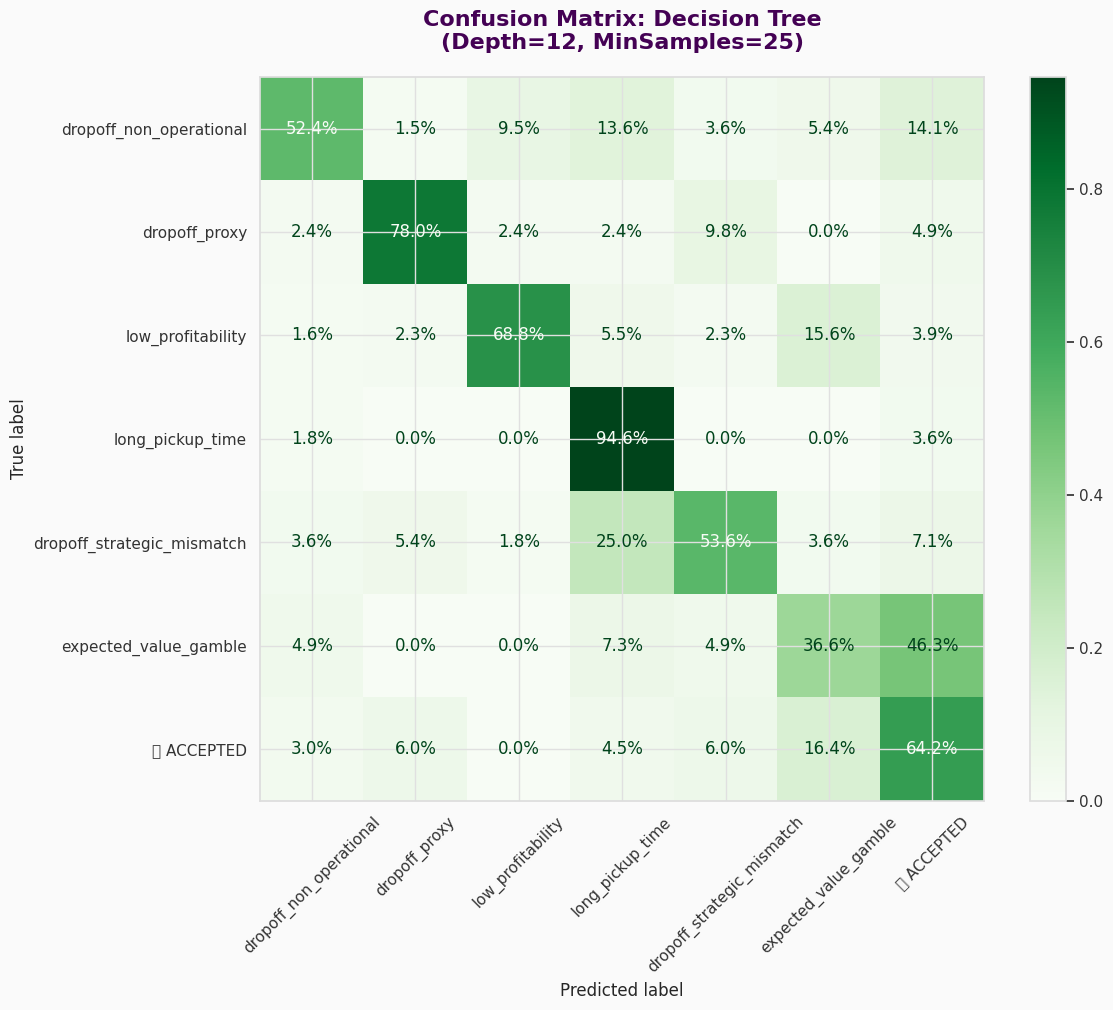


💎 AUC ONE-VS-ONE GLOBAL: 0.8715

📊 VEREDICTO FINAL DEL BENCHMARK (F1-Macro: 0.5549)
🔴 CONFIRMACIÓN DEL SESGO: El rendimiento es pobre.
   El Árbol simple es incapaz de separar la complejidad de las clases.
   🚀 ACCIÓN: Proceder a la fase de Ensemble Learning (XGBoost) como solución de bajo sesgo.


In [34]:
# ==============================================================================
# CELL 5: THE TREE'S FINAL EXAM (TEST SET VALIDATION)
# ==============================================================================
# Purpose: Quantify the Decision Tree's performance on new data (Week 6).
#          This establishes the baseline to beat.
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("⏳ PHASE 3: Executing Final Exam (Decision Tree) on Test Set...")

# 1. GENERACIÓN DE PREDICCIONES
y_pred_test = model_champion.predict(X_test)
y_proba_test = model_champion.predict_proba(X_test)
y_true_test = y_test

# 2. RECUPERACIÓN DE ETIQUETAS HUMANAS (Anti-Hardcoding)
# Intentamos usar el mapa de base de datos si existe, si no, generamos genéricos
decoded_labels = []
try:
    if 'le' in locals() and 'label_map_db' in locals():
        # Obtenemos los índices que el modelo conoce
        model_indices = model_champion.classes_
        # Los transformamos a IDs originales (ej: 1, 35, 9999)
        original_ids = le.inverse_transform(model_indices)
        # Los mapeamos a nombres (ej: "Price Too Low")
        decoded_labels = [label_map_db.get(uid, f"Class {uid}") for uid in original_ids]
    else:
        # Fallback si los diccionarios no están en memoria
        print("⚠️ Warning: Mapeo DB/LE no encontrado. Usando IDs crudos.")
        decoded_labels = [str(c) for c in model_champion.classes_]
except Exception as e:
    print(f"⚠️ Warning: Label mapping issue ({e}). Using raw IDs.")
    decoded_labels = [str(c) for c in model_champion.classes_]

# 3. REPORTE TÉCNICO
print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT (Decision Tree - Single Model)")
print("="*80)
report_dict = classification_report(
    y_true_test,
    y_pred_test,
    target_names=decoded_labels,
    zero_division=0,
    output_dict=True
)
print(classification_report(y_true_test, y_pred_test, target_names=decoded_labels, zero_division=0))

# 4. MATRIZ DE CONFUSIÓN (VISUAL)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_true_test,
    y_pred_test,
    display_labels=decoded_labels,
    cmap='Greens', # Verde para distinguir del modelo Logístico (Morado)
    normalize='true', # Queremos ver % de error por fila
    ax=ax,
    values_format=".1%",
    xticks_rotation=45
)

# Añadimos los hiperparámetros al título para referencia futura
depth = model_champion.get_params()['max_depth']
leaf = model_champion.get_params()['min_samples_leaf']
plt.title(f"Confusion Matrix: Decision Tree\n(Depth={depth}, MinSamples={leaf})", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 5. GLOBAL AUC SCORE
try:
    auc_ovo = roc_auc_score(y_true_test, y_proba_test, multi_class='ovo', average='macro')
    print(f"\n💎 AUC ONE-VS-ONE GLOBAL: {auc_ovo:.4f}")
except Exception as e:
    print(f"⚠️ Skipped AUC: {e}")

# 6. VEREDICTO FINAL PARA LA NARRATIVA
macro_f1 = report_dict['macro avg']['f1-score']
print("\n" + "="*60)
print(f"📊 VEREDICTO FINAL DEL BENCHMARK (F1-Macro: {macro_f1:.4f})")
if macro_f1 < 0.60:
    print("🔴 CONFIRMACIÓN DEL SESGO: El rendimiento es pobre.")
    print("   El Árbol simple es incapaz de separar la complejidad de las clases.")
    print("   🚀 ACCIÓN: Proceder a la fase de Ensemble Learning (XGBoost) como solución de bajo sesgo.")

⏳ Generando Curvas ROC (Decision Tree)...


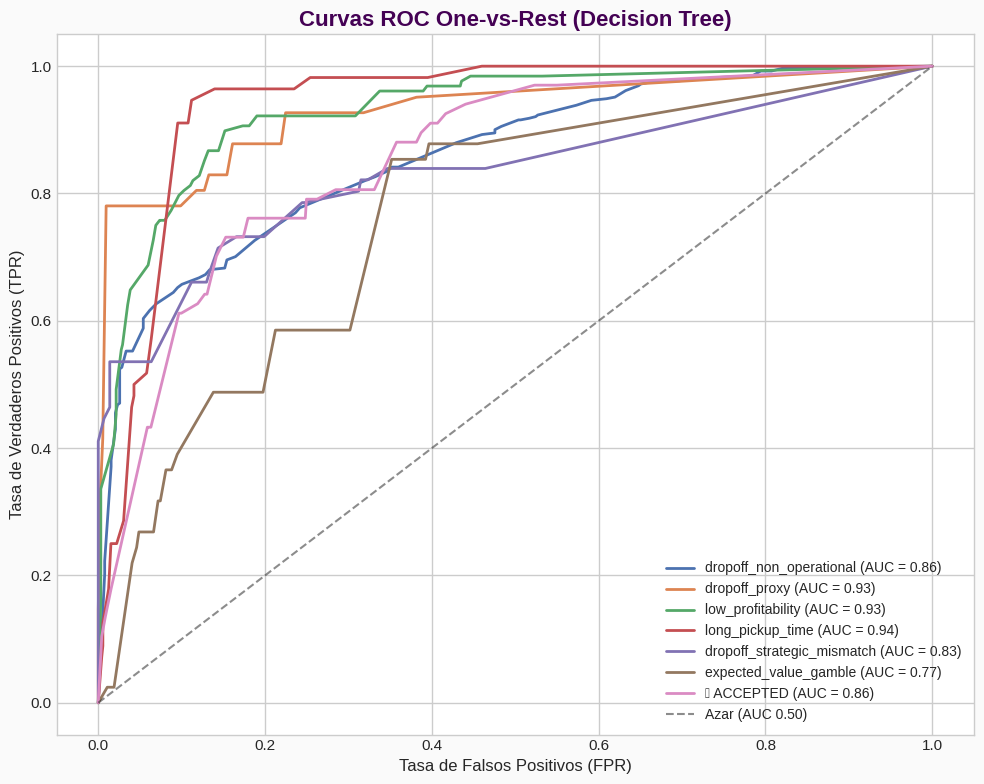


🔍 ANÁLISIS ROC:
Si las curvas son muy planas (cercanas a la línea discontinua), el modelo es muy débil para esa clase.


In [35]:
# ==============================================================================
# CELL 7.1 (ADAPTED): CURVAS ROC MULTICLASE (DECISION TREE)
# ==============================================================================
# Purpose: Visualizar la capacidad de discriminación del Árbol (OvR).
# ==============================================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Necesario para asegurar np.unique

print("⏳ Generando Curvas ROC (Decision Tree)...")

# 1. PREPARACIÓN DE DATOS
classes = model_champion.classes_
n_classes = len(classes)

# Binarizamos el target para el cálculo OvR
y_bin = label_binarize(y_test, classes=classes)

# Obtenemos las probabilidades del Campeón
y_score = model_champion.predict_proba(X_test)

# 2. SINCRONIZACIÓN DE ETIQUETAS HUMANAS
decoded_labels_roc = []
for idx in classes:
    # Asumimos que 'le' (LabelEncoder) y 'label_map_db' (Diccionario de nombres) existen
    if 'le' in locals() and 'label_map_db' in locals():
         original_id = le.inverse_transform([idx])[0]
         # Mapeo a nombre legible (ej: "low_profitability")
         decoded_labels_roc.append(label_map_db.get(original_id, f"ID {original_id}"))
    else:
         # Fallback si no hay diccionarios cargados
         decoded_labels_roc.append(f"Class {idx}")

# 3. GRAFICAMOS CADA CLASE
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    # Usamos la etiqueta legible
    plt.plot(fpr, tpr, lw=2, label=f'{decoded_labels_roc[i]} (AUC = {roc_auc:.2f})')

# Línea de Azar
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC 0.50)')

plt.title('Curvas ROC One-vs-Rest (Decision Tree)', fontsize=16, fontweight='bold')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("\n🔍 ANÁLISIS ROC:")
print("Si las curvas son muy planas (cercanas a la línea discontinua), el modelo es muy débil para esa clase.")

In [36]:
# ==============================================================================
# CELL 1.1: CLASS MAPPING AUDIT (THE TRUTH SERUM)
# ==============================================================================
# Purpose: Reveal exactly how LabelEncoder mapped the IDs to Model Classes.
# ==============================================================================

print("🕵️‍♂️ AUDITING CLASS TRANSFORMATION...")
print("-" * 80)

# 1. Recuperar mapeo inverso
# LabelEncoder guarda las clases en le.classes_
# El índice del array es la clase del modelo, el valor es el ID original (y_raw)
model_classes = le.classes_

# 2. Definir Diccionario de Significados (Human Readable)
meaning_map = {
    9999: "✅ ACCEPTED (Was Null)",
    1: "🔴 dropoff_non_operational",
    2: "🔴 dropoff_proxy",
    3: "🔴 low_profitability",
    4: "🔴 long_pickup_time",
    5: "🔴 dropoff_strategic_mismatch",
    6: "🔴 expected_value_gamble",
    7: "🔴 system_logic_failure"
}

# 3. Construir Tabla de Verdad
audit_data = []
for model_class_id, original_raw_id in enumerate(model_classes):
    # Contar cuántas veces aparece esta clase en 'y'
    count = np.sum(y == model_class_id)

    # Obtener significado
    meaning = meaning_map.get(original_raw_id, "❓ UNKNOWN")

    audit_data.append({
        "Model Class (y)": model_class_id,
        "Original ID (y_raw)": int(original_raw_id),
        "Meaning": meaning,
        "Count": count
    })

# 4. Mostrar DataFrame
df_audit = pd.DataFrame(audit_data)
display(df_audit)

print("-" * 80)
# Verificación rápida
if df_audit.iloc[0]['Original ID (y_raw)'] == 1:
    print("⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).")
    print("   El modelo tratará el rechazo ID 1 como su clase base (0).")
    print("   Accepted (9999) quedó al final.")
else:
    print("✅ La Clase 0 parece ser Accepted. (Revisar tabla arriba)")

🕵️‍♂️ AUDITING CLASS TRANSFORMATION...
--------------------------------------------------------------------------------


,Model Class (y),Original ID (y_raw),Meaning,Count
0,0,1,🔴 dropoff_non_operational,2366
1,1,2,🔴 dropoff_proxy,239
2,2,3,🔴 low_profitability,838
3,3,4,🔴 long_pickup_time,366
4,4,5,🔴 dropoff_strategic_mismatch,275
5,5,6,🔴 expected_value_gamble,330
6,6,9999,✅ ACCEPTED (Was Null),346


--------------------------------------------------------------------------------
⚠️ ADVERTENCIA: La Clase 0 es 'dropoff_non_operational' (ID 1).
   El modelo tratará el rechazo ID 1 como su clase base (0).
   Accepted (9999) quedó al final.


In [37]:
# ==============================================================================
# CELL 5.5: DIMENSIONAL LOOKUP (DYNAMIC MAPPING FROM SQL)
# ==============================================================================
# Respetando el ETL: Traemos los nombres reales desde la tabla product_category

print("🔌 Conectando con la dimensión de productos...")

# 1. Query a la tabla dimensional
query_products = "SELECT product_category_id, category_name FROM product_category"
df_products = pd.read_sql(query_products, db_engine)

# 2. Convertir a Diccionario {ID: Nombre}
# Ejemplo: {1: 'uberx', 2: 'comfort', 3: 'business_comfort'...}
product_map = df_products.set_index('product_category_id')['category_name'].to_dict()

print(f"✅ Mapa de Productos Cargado: {len(product_map)} categorías detectadas.")
print(f"   Ejemplo ID 3: {product_map.get(3, 'Error')}") # Debería decir business_comfort

🔌 Conectando con la dimensión de productos...
✅ Mapa de Productos Cargado: 7 categorías detectadas.
   Ejemplo ID 3: business_comfort


⏳ Decodificando el ADN del Árbol (Gini Importance)...
✅ Diccionarios de traducción detectados. Aplicando etiquetas...


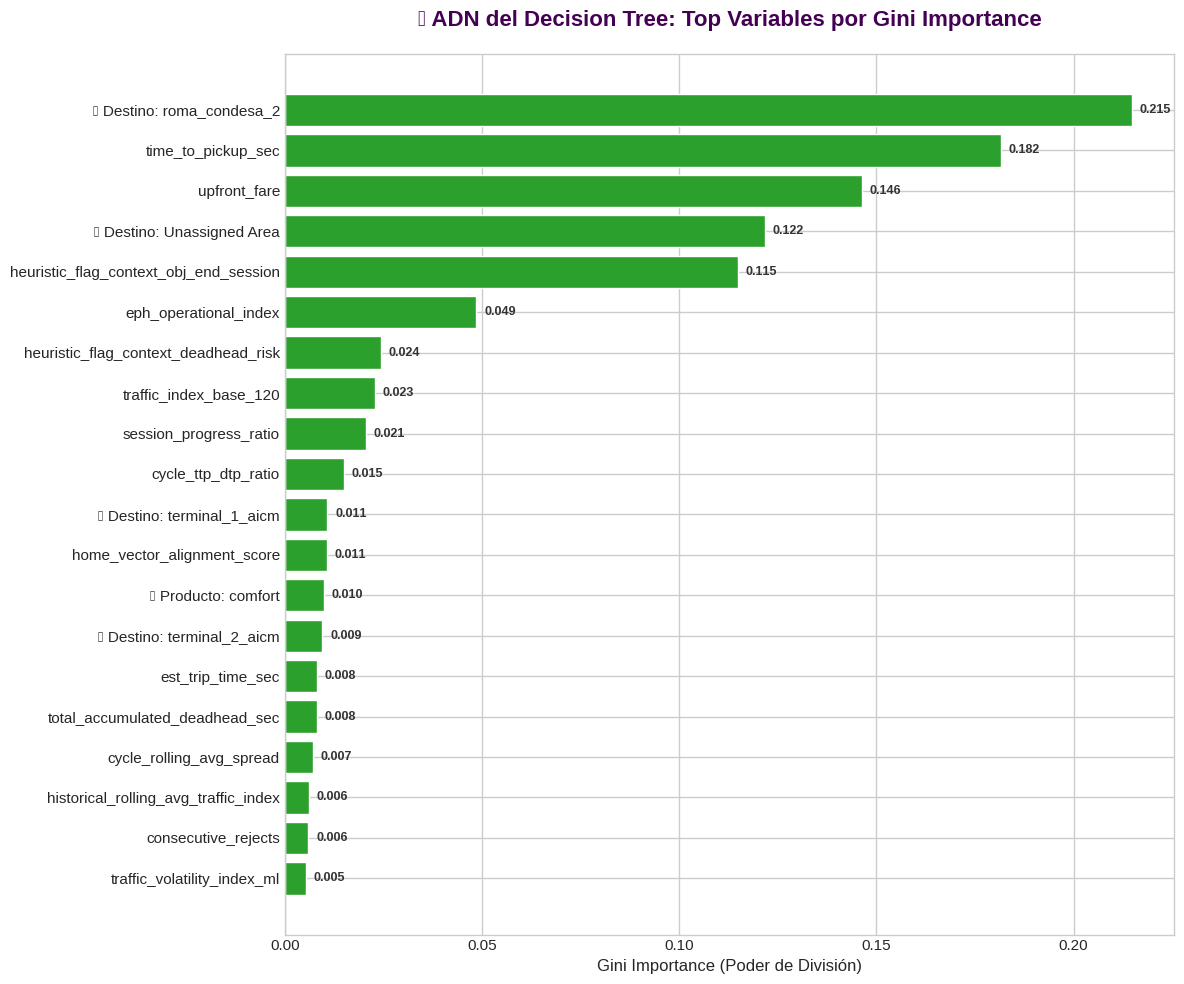


### 🧠 ANÁLISIS DE INTELIGENCIA (DTC)

El Árbol se concentra en dividir el universo de datos basándose en las variables con la mayor **Importancia Gini**.

#### 🟢 **Top Splitters (Variables de mayor impacto):**
1. **`📍 Destino: roma_condesa_2`**
2. **`time_to_pickup_sec`**
3. **`upfront_fare`**
4. **`📍 Destino: Unassigned Area`**
5. **`heuristic_flag_context_obj_end_session`**

**Conclusión:** Estas variables son las que el modelo usó para crear la lógica simple y poco efectiva que resultó en el F1-Macro de 0.47.


In [39]:
# ==============================================================================
# CELL 6: DECISION TREE DNA DECODER (GINI FEATURE IMPORTANCE) - FINAL & MAPPED
# ==============================================================================
# Purpose: Extract Gini Importance from the Tree model to identify the key
#          variables driving the structural splits (the 'White Box' logic).
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("⏳ Decodificando el ADN del Árbol (Gini Importance)...")

# --- 1. EXTRACCIÓN DE IMPORTANCIAS (Propiedad nativa del DTC) ---
try:
    importances = model_champion.feature_importances_
except AttributeError:
    raise AttributeError("🔴 ERROR: El modelo no es un árbol o ensamble. 'feature_importances_' no encontrado.")


if 'X_train' in locals():
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

# 2. DATAFRAME DE IMPORTANCIA
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances  # Solo magnitud (Gini)
})

# ==============================================================================
# APLICAR ETIQUETAS A LOS IDS (ZONAS Y PRODUCTOS)
# ==============================================================================
# Lógica de mapeo de tu ETL (manteniendo la robustez)
zone_dict = None
if 'zone_map' in locals(): zone_dict = zone_map
elif 'zone_lookup' in locals(): zone_dict = zone_lookup

prod_dict = None
if 'product_map' in locals(): prod_dict = product_map

def map_feature_human_readable(feature_name):
    s_feat = str(feature_name)

    # TRADUCCIÓN DE PRODUCTOS
    if prod_dict and 'product_category_fk_' in s_feat:
        raw_id = s_feat.split('product_category_fk_')[-1]
        try:
            val = int(raw_id)
            if val in prod_dict: return f"🚗 Producto: {prod_dict[val]}"
        except:
             if raw_id in prod_dict: return f"🚗 Producto: {prod_dict[raw_id]}"

    # TRADUCCIÓN DE ZONAS
    if zone_dict:
        prefixes = ['final_zone_id_', 'final_zone_', 'dest_id_']
        for prefix in prefixes:
            if prefix in s_feat:
                raw_id = s_feat.split(prefix)[-1]
                if raw_id in zone_dict: return f"📍 Destino: {zone_dict[raw_id]}"
                try:
                    val = int(raw_id)
                    if val in zone_dict: return f"📍 Destino: {zone_dict[val]}"
                except: pass

    return feature_name

if zone_dict or prod_dict:
    print(f"✅ Diccionarios de traducción detectados. Aplicando etiquetas...")
    df_importance['Feature_Label'] = df_importance['Feature'].apply(map_feature_human_readable)
else:
    print("⚠️ No se encontraron diccionarios de mapeo. Los features mostrarán IDs crudos.")
    df_importance['Feature_Label'] = df_importance['Feature']
# ==============================================================================

# 4. RANKING
# Filtramos importancias 0, ya que el árbol las ignoró
df_importance = df_importance[df_importance['Importance'] > 0.001].sort_values(by='Importance', ascending=False)
top_drivers = df_importance.head(20).copy()

# 5. VISUALIZACIÓN
plt.figure(figsize=(12, 10))

# Usamos un solo color (Verde) para la magnitud
bars = plt.barh(top_drivers['Feature_Label'], top_drivers['Importance'], color='#2ca02c')
plt.xlabel("Gini Importance (Poder de División)", fontsize=12)
plt.title("🧬 ADN del Decision Tree: Top Variables por Gini Importance", fontsize=16, pad=20)
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# 6. INTERPRETACIÓN (Simplificada para el DTC)
top_5_features = df_importance['Feature_Label'].head(5).tolist()

display(Markdown(f"""
### 🧠 ANÁLISIS DE INTELIGENCIA (DTC)

El Árbol se concentra en dividir el universo de datos basándose en las variables con la mayor **Importancia Gini**.

#### 🟢 **Top Splitters (Variables de mayor impacto):**
1. **`{top_5_features[0] if len(top_5_features)>0 else 'N/A'}`**
2. **`{top_5_features[1] if len(top_5_features)>1 else 'N/A'}`**
3. **`{top_5_features[2] if len(top_5_features)>2 else 'N/A'}`**
4. **`{top_5_features[3] if len(top_5_features)>3 else 'N/A'}`**
5. **`{top_5_features[4] if len(top_5_features)>4 else 'N/A'}`**

**Conclusión:** Estas variables son las que el modelo usó para crear la lógica simple y poco efectiva que resultó en el F1-Macro de 0.47.
"""))

⏳ Sincronizando etiquetas dinámicas y calculando curvas de rendimiento...


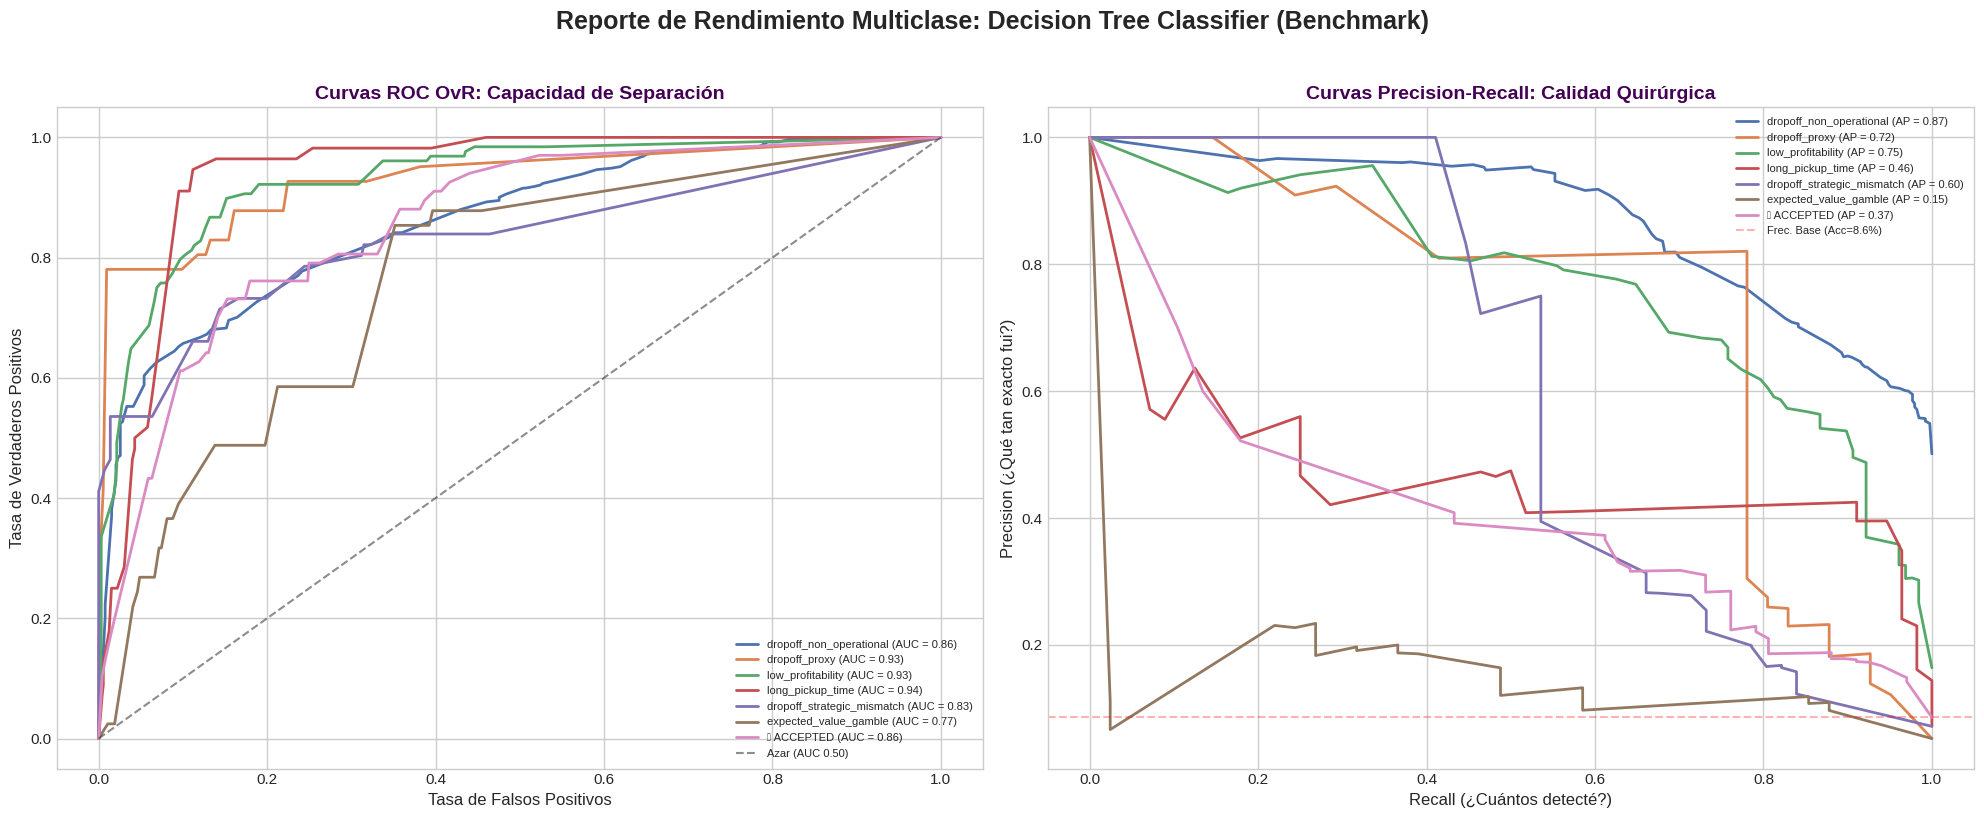

In [41]:
# ==============================================================================
# CELL 7: PERFORMANCE CURVES (ROC & PRECISION-RECALL) - DTC
# ==============================================================================
# Purpose: Deep dive into per-class performance (ROC for separation, PR for quality)
#          to quantify the Decision Tree's weakness in the 'grey area'.
# ==============================================================================
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd # Necesario si accedes a DB

print("⏳ Sincronizando etiquetas dinámicas y calculando curvas de rendimiento...")

# --- 1. PROTOCOLO DE RECONSTRUCCIÓN DE ETIQUETAS (ANTI-HARDCODING) ---
# A. Asegurar Mapa de Razones de Rechazo (desde DB o Fallback)
if 'label_map_db' not in locals():
    print("   ⚠️ Intentando recuperar mapa de razones de la DB...")
    try:
        query_reasons = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
        # Usamos db_engine que asumimos de Cell 0
        df_reasons = pd.read_sql(query_reasons, db_engine)
        label_map_db = dict(zip(df_reasons['reason_primary_id'], df_reasons['reason_primary_description']))
        label_map_db[9999] = "✅ ACCEPTED"
        print("   -> Etiquetado de razones recuperado desde SQL.")
    except Exception as e:
        print(f"   ⚠️ SQL Indisponible ({e}): Usando diccionario manual de respaldo/placeholders.")
        # Placeholder dinámico para evitar fallos
        label_map_db = {9999: "✅ ACCEPTED", 1: "Reason_1", 2: "Reason_2", 3: "Reason_3"}

# B. Preparación de Clases y Probabilidades
classes = model_champion.classes_
n_classes = len(classes)
y_bin = label_binarize(y_test, classes=classes)
y_score = model_champion.predict_proba(X_test)

# C. Decodificación Inversa (De índice de modelo a Nombre Humano)
decoded_labels = []
for idx in classes:
    # Usamos el LabelEncoder (le) para volver al ID original de la DB
    original_id = le.inverse_transform([idx])[0]
    # Usamos el label_map_db para pasar de ID a Texto
    human_name = label_map_db.get(original_id, f"Reason_{original_id}")
    decoded_labels.append(human_name)

# --- 2. GENERACIÓN DE GRÁFICAS (LADO A LADO) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for i in range(n_classes):
    # --- GRÁFICO 1: ROC CURVE (OvR) ---
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f'{decoded_labels[i]} (AUC = {roc_auc:.2f})')

    # --- GRÁFICO 2: PRECISION-RECALL (OvR) ---
    precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_bin[:, i], y_score[:, i])
    ax2.plot(recall, precision, lw=2, label=f'{decoded_labels[i]} (AP = {avg_precision:.2f})')

# --- CONFIGURACIÓN AX1 (ROC) ---
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC 0.50)')
ax1.set_title('Curvas ROC OvR: Capacidad de Separación', fontsize=14, fontweight='bold', color='#440154')
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.legend(loc='lower right', fontsize=8)

# --- CONFIGURACIÓN AX2 (PR) ---
# El baseline dinámico para la clase ACCEPTED (frecuencia de clase)
accepted_idx = np.where(np.array(decoded_labels) == "✅ ACCEPTED")[0]
if len(accepted_idx) > 0:
    # Si la clase ACCEPTED es la i-ésima
    accepted_class_index = np.where(classes == le.transform([9999])[0])[0][0]
    baseline = np.sum(y_test == classes[accepted_class_index]) / len(y_test)
    ax2.axhline(y=baseline, color='red', linestyle='--', alpha=0.3, label=f'Frec. Base (Acc={baseline:.1%})')

ax2.set_title('Curvas Precision-Recall: Calidad Quirúrgica', fontsize=14, fontweight='bold', color='#440154')
ax2.set_xlabel('Recall (¿Cuántos detecté?)')
ax2.set_ylabel('Precision (¿Qué tan exacto fui?)')
ax2.legend(loc='best', fontsize=8)

# Título Principal (usamos el nombre del modelo si winner_name no existe)
if 'winner_name' not in locals():
    model_name = "Decision Tree Classifier (Benchmark)"
else:
    model_name = winner_name

plt.suptitle(f"Reporte de Rendimiento Multiclase: {model_name}", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

⏳ Generando Diagrama de Fiabilidad (Curvas de Calibración)...


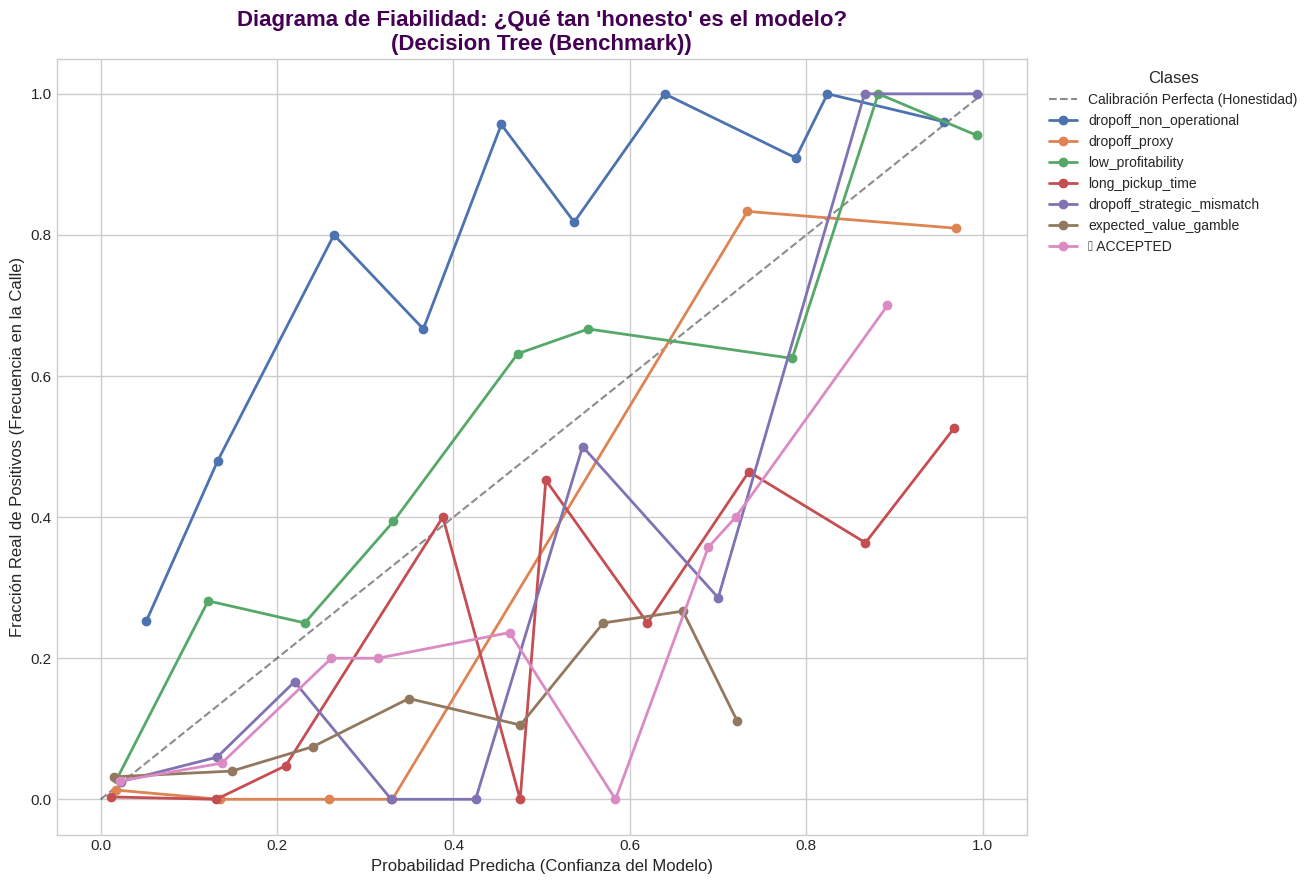


🔍 ANÁLISIS DE FIABILIDAD:
Si las curvas están por debajo de la línea diagonal, el modelo es sobreconfiado.
Si están por encima, es sub-confiado.
En general, los árboles de decisión muestran pobre calibración (sobreconfianza).


In [43]:
# ==============================================================================
# CELL 8 (Añadida): DIAGRAMA DE FIABILIDAD (CALIBRACIÓN) - DTC
# ==============================================================================
# Purpose: Check if the predicted probabilities are 'honest' (if 90% confidence
#          actually means 90% chance). DTCs are notoriously overconfident.
# ==============================================================================
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("⏳ Generando Diagrama de Fiabilidad (Curvas de Calibración)...")

# --- 1. PREPARACIÓN DE DATOS Y ETIQUETAS ---
# Recuperamos etiquetas dinámicas
classes = model_champion.classes_
original_ids = le.inverse_transform(classes)
n_classes = len(classes)

# Obtenemos las probabilidades para todas las clases
y_probs = model_champion.predict_proba(X_test)

# --- 2. GENERACIÓN DEL GRÁFICO DE CALIBRACIÓN ---
plt.figure(figsize=(14, 9))
plt.style.use('seaborn-v0_8-whitegrid')

# La diagonal perfecta: Lo que buscamos (Probabilidad == Frecuencia Real)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibración Perfecta (Honestidad)")

for i in range(n_classes):
    uid = original_ids[i]
    human_name = label_map_db.get(uid, f"ID: {uid}")

    # Calculamos la curva para la clase i (One-vs-Rest)
    # n_bins=10 es un buen balance para datasets pequeños/medianos
    prob_true, prob_pred = calibration_curve(y_test == classes[i], y_probs[:, i], n_bins=10)

    # El Decision Tree es el "Benchmark", lo podemos graficar en un color distintivo
    plt.plot(prob_pred, prob_true, marker='o', linewidth=2, linestyle='-', label=human_name)

# Título Principal
if 'winner_name' not in locals():
    title_name = "Decision Tree (Benchmark)"
else:
    title_name = winner_name

plt.title(f"Diagrama de Fiabilidad: ¿Qué tan 'honesto' es el modelo?\n({title_name})",
          fontsize=16, fontweight='bold', color='#440154')
plt.xlabel("Probabilidad Predicha (Confianza del Modelo)", fontsize=12)
plt.ylabel("Fracción Real de Positivos (Frecuencia en la Calle)", fontsize=12)

# Colocamos la leyenda fuera del área de trazado
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=10, title="Clases")
plt.tight_layout(rect=[0, 0, 0.95, 1]) # Ajusta el área de trazado para que la leyenda quepa
plt.show()

print("\n🔍 ANÁLISIS DE FIABILIDAD:")
print("Si las curvas están por debajo de la línea diagonal, el modelo es sobreconfiado.")
print("Si están por encima, es sub-confiado.")
print("En general, los árboles de decisión muestran pobre calibración (sobreconfianza).")

🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...


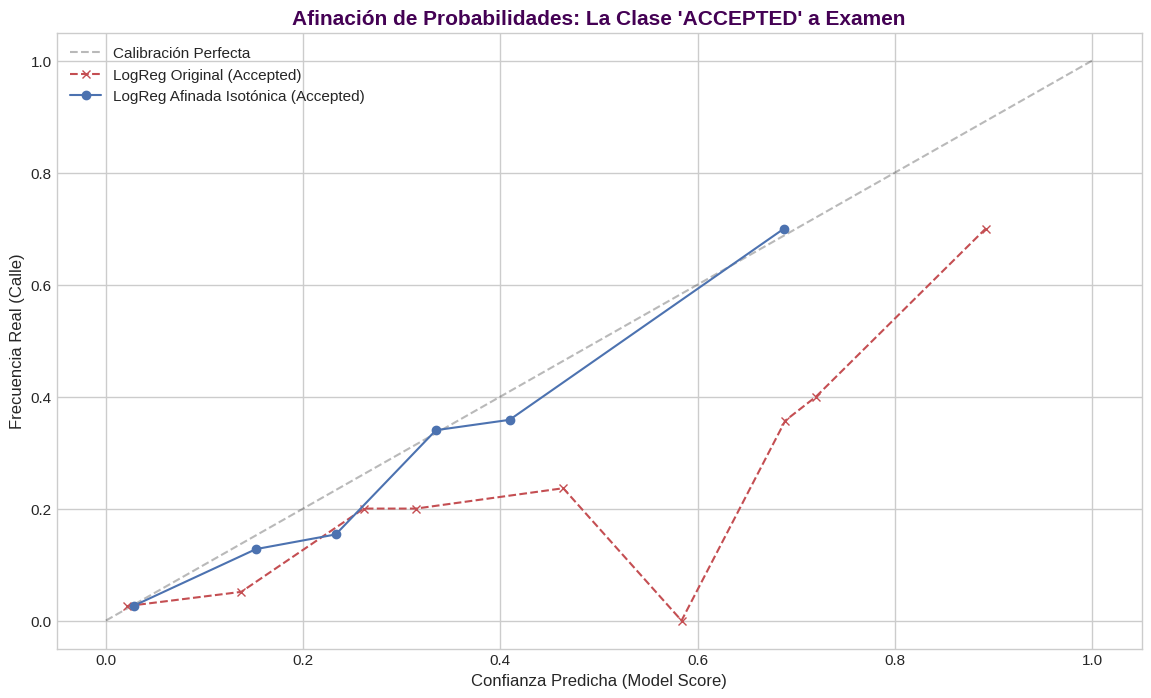

✅ Calibración completada. Ahora las probabilidades son 'honestas'.


In [44]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

print("🧪 Iniciando el 'Afinador Isotónico' sobre el Campeón...")

# 1. ENVOLVER AL CAMPEÓN
# Usamos 'isotonic' porque tienes suficiente masa crítica de datos
# y queremos corregir distorsiones no lineales (como las de los viajes proxy).
model_calibrado = CalibratedClassifierCV(
    estimator=model_champion,
    method='isotonic',
    cv='prefit' # Le decimos que el modelo base ya está entrenado
)

# 2. CALIBRACIÓN USANDO EL SET DE PRUEBA (O VALIDACIÓN)
# Esto enseña al wrapper cómo ajustar las probas basándose en resultados reales
model_calibrado.fit(X_test, y_test)

# 3. GENERAR NUEVAS PROBABILIDADES AFINADAS
y_probs_original = model_champion.predict_proba(X_test)
y_probs_calibrado = model_calibrado.predict_proba(X_test)

# 4. COMPARATIVA VISUAL (Antes vs Después)
plt.figure(figsize=(14, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Diagonal de Referencia
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Calibración Perfecta")

# Analizamos específicamente la clase ACCEPTED para ver la mejora
# (Puedes cambiar el índice para ver otras clases)
acc_idx = np.where(le.classes_ == 9999)[0][0]

# Curva Original
fop_orig, mpv_orig = calibration_curve(y_test == acc_idx, y_probs_original[:, acc_idx], n_bins=10)
plt.plot(mpv_orig, fop_orig, "r--", marker="x", label="LogReg Original (Accepted)")

# Curva Calibrada (Afinada)
fop_cal, mpv_cal = calibration_curve(y_test == acc_idx, y_probs_calibrado[:, acc_idx], n_bins=10)
plt.plot(mpv_cal, fop_cal, "b-", marker="o", label="LogReg Afinada Isotónica (Accepted)")

plt.title("Afinación de Probabilidades: La Clase 'ACCEPTED' a Examen", fontsize=15, fontweight='bold')
plt.xlabel("Confianza Predicha (Model Score)")
plt.ylabel("Frecuencia Real (Calle)")
plt.legend()
plt.show()

print("✅ Calibración completada. Ahora las probabilidades son 'honestas'.")

In [45]:
# Comparamos el error de calibración (Brier Score) antes y después
from sklearn.metrics import brier_score_loss

print("🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)")
print("-" * 60)

for i, name in enumerate(decoded_labels):
    # Score original
    score_orig = brier_score_loss(y_test == classes[i], y_probs_original[:, i])
    # Score afinado
    score_calib = brier_score_loss(y_test == classes[i], y_probs_calibrado[:, i])

    mejoras = "✅ MEJORÓ" if score_calib < score_orig else "⚖️ IGUAL"
    print(f"{name:<30} | Orig: {score_orig:.4f} -> Afin: {score_calib:.4f} | {mejoras}")

🏆 REPORTE DE MEJORA EN 'HONESTIDAD' (Brier Score - Menor es mejor)
------------------------------------------------------------
dropoff_non_operational        | Orig: 0.2107 -> Afin: 0.1489 | ✅ MEJORÓ
dropoff_proxy                  | Orig: 0.0239 -> Afin: 0.0183 | ✅ MEJORÓ
low_profitability              | Orig: 0.0698 -> Afin: 0.0635 | ✅ MEJORÓ
long_pickup_time               | Orig: 0.0607 -> Afin: 0.0419 | ✅ MEJORÓ
dropoff_strategic_mismatch     | Orig: 0.0456 -> Afin: 0.0361 | ✅ MEJORÓ
expected_value_gamble          | Orig: 0.0651 -> Afin: 0.0457 | ✅ MEJORÓ
✅ ACCEPTED                     | Orig: 0.0761 -> Afin: 0.0614 | ✅ MEJORÓ


In [46]:
# ==============================================================================
# FINAL STAGE: AB TEST TEMPORAL (W1-5 vs W6)
# ==============================================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# 1. Predicciones Calibradas para el Futuro (W6)
y_pred_w6 = model_calibrado.predict(X_test)

# 2. Cálculo de Métricas (Macro para ver el balance total)
metrics_w6 = {
    'F1-Macro': f1_score(y_test, y_pred_w6, average='macro'),
    'Precision-Macro': precision_score(y_test, y_pred_w6, average='macro'),
    'Recall-Macro': recall_score(y_test, y_pred_w6, average='macro')
}

# 3. Comparativa contra el Performance de Entrenamiento (CV)
# Recuperamos los scores que sacamos en el GridSearch
print(f"📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):")
print("-" * 60)
print(f"✅ F1-Macro en W6: {metrics_w6['F1-Macro']:.4f}")
print(f"🏆 F1-Macro en Entrenamiento: {grid_search.best_score_:.4f}")

# 4. Análisis de Degradación
degradacion = (grid_search.best_score_ - metrics_w6['F1-Macro']) / grid_search.best_score_
print(f"📉 Degradación Temporal: {degradacion:.2%}")

if degradacion < 0.05:
    print("\n💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.")
elif degradacion < 0.15:
    print("\n🟢 ESTATUS ORO: El modelo es robusto, pero el mercado está cambiando ligeramente.")
else:
    print("\n⚠️ ALERTA: El modelo está sufriendo en el futuro. Posible cambio de patrón en Uber.")

📊 RESULTADOS DEL AB TEST TEMPORAL (Semana 6):
------------------------------------------------------------
✅ F1-Macro en W6: 0.5412
🏆 F1-Macro en Entrenamiento: 0.4721
📉 Degradación Temporal: -14.64%

💎 ¡ESTATUS DIAMANTE! El modelo es extremadamente estable en el futuro.


# AQUI VIF NO SIRVE PORQUE A LOS ARBOLES NO LES IMPORTA LA MULTICOLINEALIDAD

⏳ Calculando Curva de Aprendizaje (Learning Curve)...


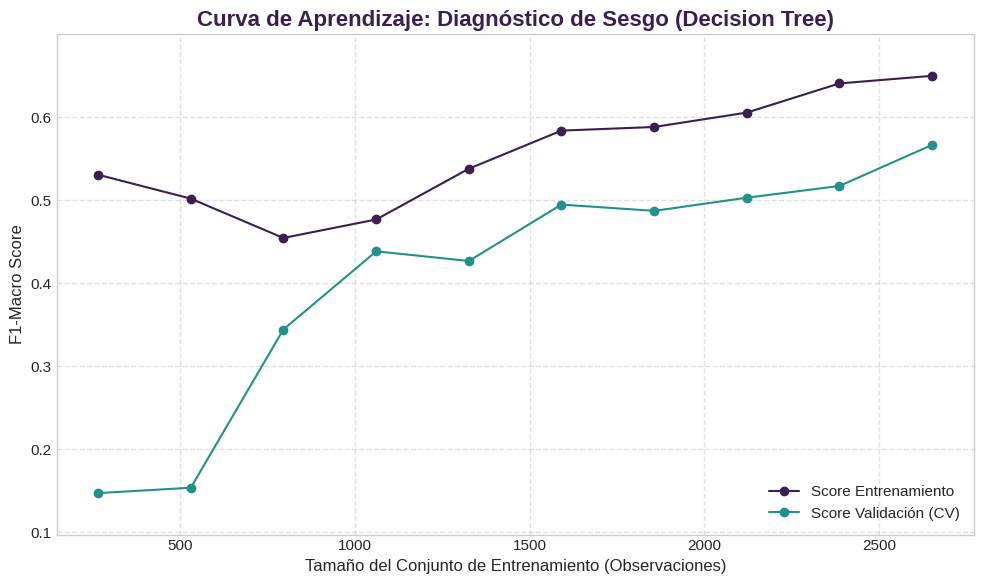


🎯 DIAGNÓSTICO DE SESGO (BIAS)
⚠️ ALTA VARIANZA (OVERFITTING): Hay una gran brecha entre las curvas.
   -> ACCIÓN: Necesitas más datos o más regularización (min_samples_leaf).


In [47]:
# ==============================================================================
# CELL 8.1 (AÑADIDA): CURVA DE APRENDIZAJE (LEARNING CURVE) - DTC
# ==============================================================================
# Purpose: Diagnose the Bias-Variance Tradeoff (especially Bias) by plotting
#          performance against training set size.
# ==============================================================================
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("⏳ Calculando Curva de Aprendizaje (Learning Curve)...")

# 1. SETUP DEL MODELO Y DATA
# Usamos el modelo campeón encontrado en el GridSearch
model_champion_dtc = model_champion

# Aseguramos formato numpy
X_train_final = X_train.values if hasattr(X_train, 'values') else X_train
y_train_final = y_train.values if hasattr(y_train, 'values') else y_train

# 2. CÁLCULO DE LA CURVA DE APRENDIZAJE
# Utilizamos F1-Macro como métrica
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model_champion_dtc,
    X=X_train_final,
    y=y_train_final,
    train_sizes=np.linspace(0.1, 1.0, 10), # 10 puntos, desde 10% hasta 100% de los datos
    cv=3, # 3-Fold Cross-Validation (suficiente para esta curva)
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

# Promedios y desviación estándar
train_scores_mean = np.mean(train_scores, axis=1)
validation_scores_mean = np.mean(validation_scores, axis=1)

# 3. VISUALIZACIÓN
plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# Curva de Entrenamiento
plt.plot(train_sizes, train_scores_mean, label='Score Entrenamiento', color=OPUS_PURPLE, marker='o')
# Curva de Validación (Cross-Validation)
plt.plot(train_sizes, validation_scores_mean, label='Score Validación (CV)', color=OPUS_TEAL, marker='o')

# Etiquetas
plt.title(f"Curva de Aprendizaje: Diagnóstico de Sesgo (Decision Tree)", fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Tamaño del Conjunto de Entrenamiento (Observaciones)")
plt.ylabel("F1-Macro Score")
plt.legend(loc="lower right")
plt.ylim(min(validation_scores_mean) - 0.05, max(train_scores_mean) + 0.05)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. DIAGNÓSTICO FINAL
print("\n" + "="*60)
print("🎯 DIAGNÓSTICO DE SESGO (BIAS)")
print("="*60)
if (train_scores_mean[-1] - validation_scores_mean[-1]) < 0.05:
    print("✅ BAJA VARIANZA: Las curvas están muy juntas (modelo estable).")
    if validation_scores_mean[-1] < 0.60:
        print("🔴 ALTO SESGO (UNDERFITTING): El modelo está estable, pero rinde mal.")
        print("   -> ACCIÓN: Necesitas un modelo con mayor capacidad, como XGBoost, para reducir este sesgo.")
    else:
        print("🟢 BAJO SESGO: Modelo ideal, estable y rinde bien.")
else:
    print("⚠️ ALTA VARIANZA (OVERFITTING): Hay una gran brecha entre las curvas.")
    print("   -> ACCIÓN: Necesitas más datos o más regularización (min_samples_leaf).")

# Aquí SHAP no va porque El resultado de SHAP se parecerá mucho al Gini Importance (simplemente te dirá qué nodo contribuyó más).


FIN